# VIPER Model — SHAP Analysis

**Pipeline stage:** 4 of 6  
**Input:** `rf_model_tuned.pkl`, `train_test_splits.pkl`, `feature_cols.pkl`  
**Outputs:** `shap_values.pkl`, figures `shap_01_` → `shap_03_`  

---

## Contents
1. [Imports & Load Artefacts](#1-imports--load-artefacts)
2. [SHAP Explainer & Value Computation](#2-shap-explainer--value-computation)
3. [Global Feature Importance (Bar)](#3-global-feature-importance)
4. [Beeswarm Plot](#4-beeswarm-plot)
5. [Dependence Plots — Top 3 Features](#5-dependence-plots)
6. [Summary Table & Artefact Export](#6-summary-table--artefact-export)


## 1. Imports & Load Artefacts

In [1]:
import pandas as pd
import numpy as np
import pickle
import shap
import matplotlib.pyplot as plt

with open('rf_model_tuned.pkl', 'rb') as f:
    rf_best = pickle.load(f)

with open('train_test_splits.pkl', 'rb') as f:
    splits  = pickle.load(f)
    X_train = splits['X_train']
    X_test  = splits['X_test']
    y_train = splits['y_train']
    y_test  = splits['y_test']

with open('feature_cols.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

# Human-readable display names (same order as feature_cols)
feature_names = [
    'CADD PHRED', 'MAX AF', 'PolyPhen Score',
    'IMPACT', 'Variant Class', 'Biotype',
    'SIFT Category', 'PolyPhen Category', 'Consequence'
]

print(f'Model:       {rf_best}')
print(f'X_test:      {X_test.shape}')
print(f'Features:    {feature_cols}')

/home/nayeema/ml_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model:       RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=2, n_estimators=300, n_jobs=-1,
                       random_state=42)
X_test:      (12749, 9)
Features:    ['PHRED', 'MAX_AF', 'PolyPhen_score', 'IMPACT_encoded', 'VARIANT_CLASS_encoded', 'BIOTYPE_encoded', 'SIFT_cat_encoded', 'PolyPhen_cat_encoded', 'Consequence_grouped_encoded']


## 2. SHAP Explainer & Value Computation

Using `TreeExplainer` (exact, fast for tree ensembles).  
SHAP values computed on a stratified random sample of 1,000 test-set variants —  
sufficient for stable global importance estimates.


In [2]:
print('Initializing SHAP TreeExplainer...')
explainer = shap.TreeExplainer(rf_best)

np.random.seed(42)
sample_idx = np.random.choice(len(X_test), size=1000, replace=False)
X_shap = X_test.iloc[sample_idx]

print(f'Computing SHAP values for {len(X_shap)} samples...')
shap_values = explainer.shap_values(X_shap)

# shap_values shape: (n_samples, n_features, n_classes)
# Index class 1 (Pathogenic) for all downstream plots
shap_vals_patho = shap_values[:, :, 1]

print(f'SHAP values shape: {np.array(shap_values).shape}')
print(f'Pathogenic SHAP slice: {shap_vals_patho.shape}')

Initializing SHAP TreeExplainer...
Computing SHAP values for 1000 samples...
SHAP values shape: (1000, 9, 2)
Pathogenic SHAP slice: (1000, 9)


## 3. Global Feature Importance (Bar)

Mean absolute SHAP value per feature — ranks features by average impact on  
Pathogenic classification across all 1,000 samples.  
`→ saves: shap_01_global_importance.png`


/tmp/ipykernel_9867/1979806873.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


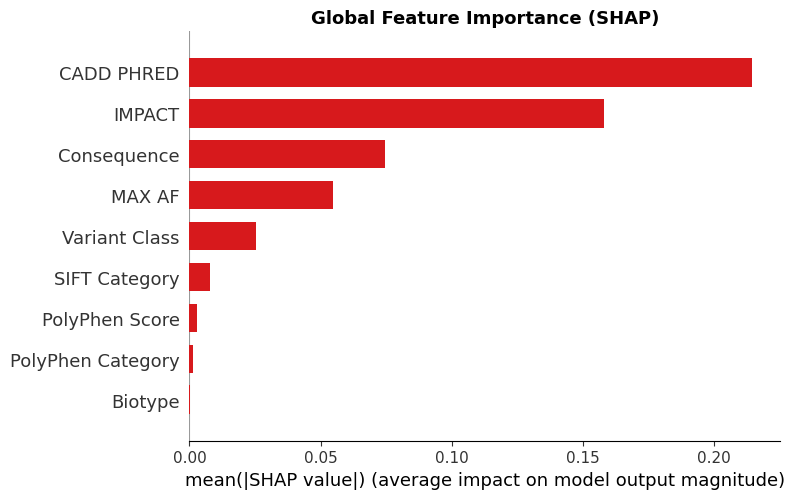

Saved: shap_01_global_importance.png


In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
shap.summary_plot(
    shap_vals_patho, X_shap,
    feature_names=feature_names,
    plot_type='bar',
    color='#D7191C',
    show=False
)
plt.title('Global Feature Importance (SHAP)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_01_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_01_global_importance.png')

## 4. Beeswarm Plot

Shows both the magnitude and direction of each feature's effect.  
Colour = feature value (red = high, blue = low).  
`→ saves: shap_02_beeswarm.png`


/tmp/ipykernel_9867/497145821.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


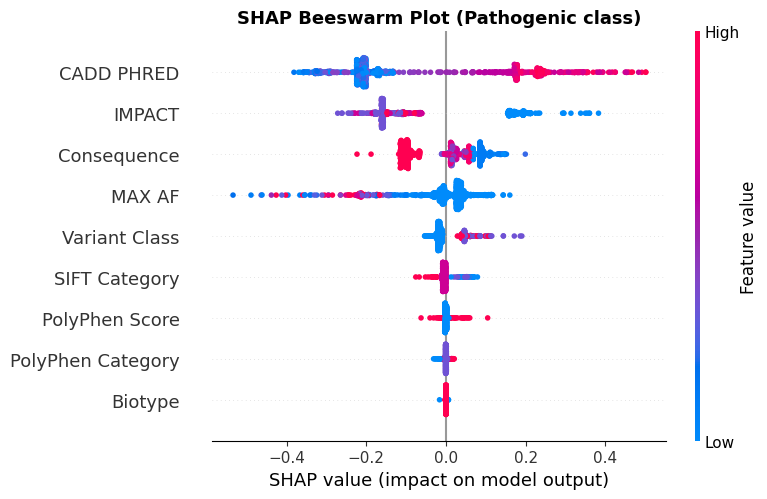

Saved: shap_02_beeswarm.png


In [4]:
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    shap_vals_patho, X_shap,
    feature_names=feature_names,
    show=False
)
plt.title('SHAP Beeswarm Plot (Pathogenic class)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_02_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_02_beeswarm.png')

## 5. Dependence Plots — Top 3 Features

Each plot shows how a feature's value maps to its SHAP contribution,  
with interaction colouring auto-selected by SHAP.  
Top 3 by mean |SHAP|: CADD PHRED, MAX AF, PolyPhen Score.  
`→ saves: shap_03_dependence.png`


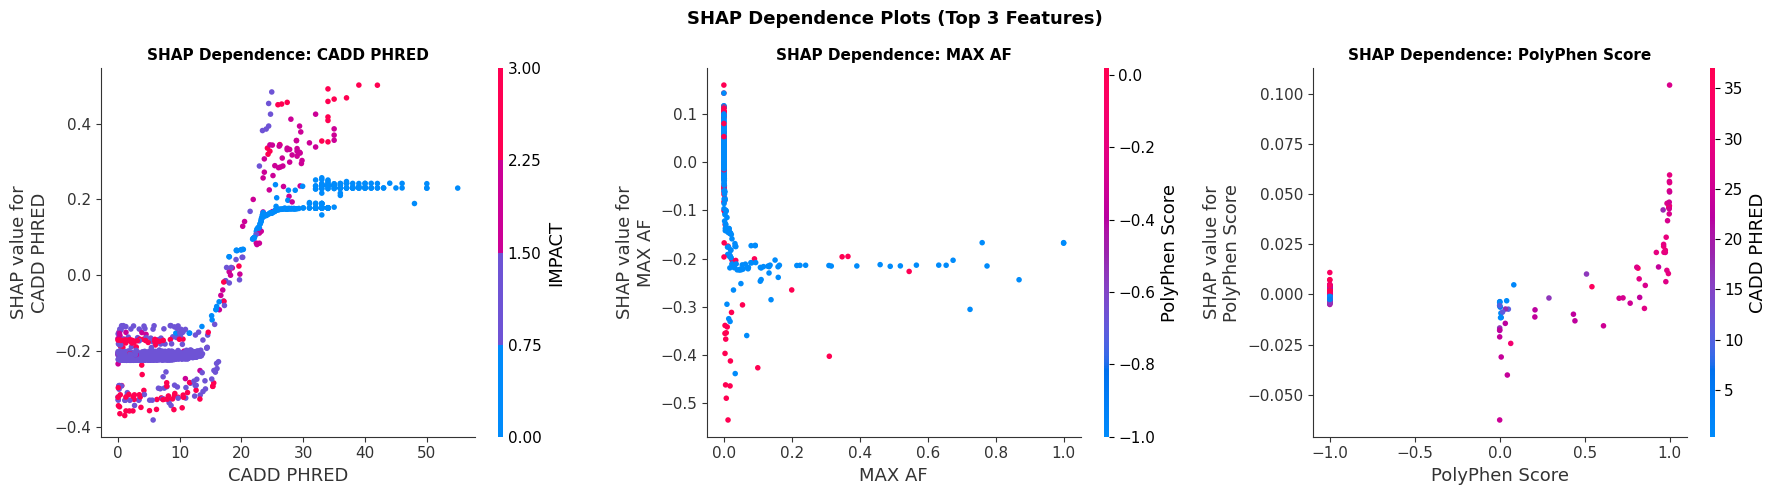

Saved: shap_03_dependence.png


In [5]:
top_features = ['CADD PHRED', 'MAX AF', 'PolyPhen Score']
top_idx      = [0, 1, 2]  # indices in feature_names / feature_cols

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feat_idx, feat_name in zip(axes, top_idx, top_features):
    shap.dependence_plot(
        feat_idx, shap_vals_patho, X_shap,
        feature_names=feature_names,
        ax=ax, show=False
    )
    ax.set_title(f'SHAP Dependence: {feat_name}', fontsize=11, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('SHAP Dependence Plots (Top 3 Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_03_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_03_dependence.png')

## 6. Summary Table & Artefact Export

Print ranked feature importance table and pickle SHAP values for downstream use  
(e.g. VUS reclassification, ENIGMA validation).


In [6]:
mean_shap = pd.DataFrame({
    'Feature':     feature_names,
    'Mean |SHAP|': np.abs(shap_vals_patho).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)

print('Global Feature Importance (Mean |SHAP| — Pathogenic class):')
print(mean_shap.to_string(index=False))

Global Feature Importance (Mean |SHAP| — Pathogenic class):
          Feature  Mean |SHAP|
       CADD PHRED     0.214343
           IMPACT     0.158015
      Consequence     0.074693
           MAX AF     0.054766
    Variant Class     0.025383
    SIFT Category     0.007962
   PolyPhen Score     0.002815
PolyPhen Category     0.001478
          Biotype     0.000254


In [7]:
with open('shap_values.pkl', 'wb') as f:
    pickle.dump({
        'shap_values':  shap_values,
        'shap_vals_patho': shap_vals_patho,
        'X_shap':       X_shap,
        'feature_names': feature_names,
        'sample_idx':   sample_idx
    }, f)
print('Saved: shap_values.pkl')

Saved: shap_values.pkl
